In [1]:
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 300
import stylia
import pandas as pd
import numpy as np
import zipfile
import io
import os

In [2]:
PATHOGENS = {
    "abaumannii":    "Acinetobacter baumannii",
    "calbicans":     "Candida albicans",
    "campylobacter": "Campylobacter",
    "ecoli":         "Escherichia coli",
    "efaecium":      "Enterococcus faecium",
    "enterobacter":  "Enterobacter",
    "hpylori":       "Helicobacter pylori",
    "kpneumoniae":   "Klebsiella pneumoniae",
    "mtuberculosis": "Mycobacterium tuberculosis",
    "ngonorrhoeae":  "Neisseria gonorrhoeae",
    "paeruginosa":   "Pseudomonas aeruginosa",
    "pfalciparum":   "Plasmodium falciparum",
    "saureus":       "Staphylococcus aureus",
    "smansoni":      "Schistosoma mansoni",
    "spneumoniae":   "Streptococcus pneumoniae",
}

PATH_TO_OUTPUT = os.path.join(".", "..", "output")

MIN_CPDS_A = 1000
MIN_POS_A  = 50
MIN_POS_B  = 100

def qualifies_a(row):
    try:
        return (row["dataset_type"] in ("quantitative", "mixed")
                and float(row["cpds_qt"]) >= MIN_CPDS_A
                and float(row["pos_qt"]) >= MIN_POS_A
                and float(row["ratio_qt"]) < 0.5)
    except (ValueError, KeyError):
        return False

def qualifies_b(row):
    try:
        return (row["dataset_type"] in ("quantitative", "mixed")
                and float(row["pos_qt"]) >= MIN_POS_B
                and float(row["ratio_qt"]) >= 0.5)
    except (ValueError, KeyError):
        return False

def n_assays(df):
    if len(df) == 0:
        return 0
    return len(df[["assay_id", "activity_type", "unit"]].drop_duplicates())

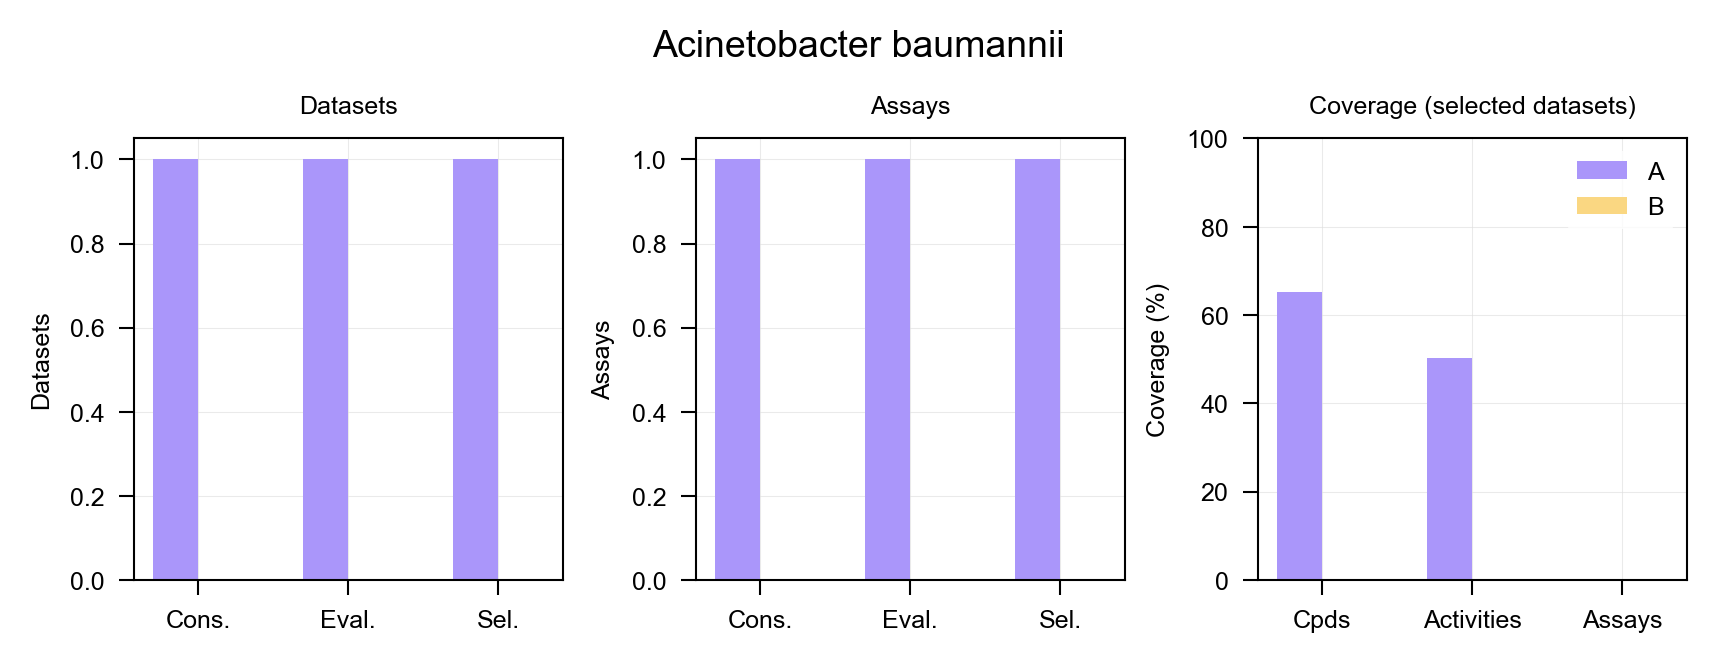

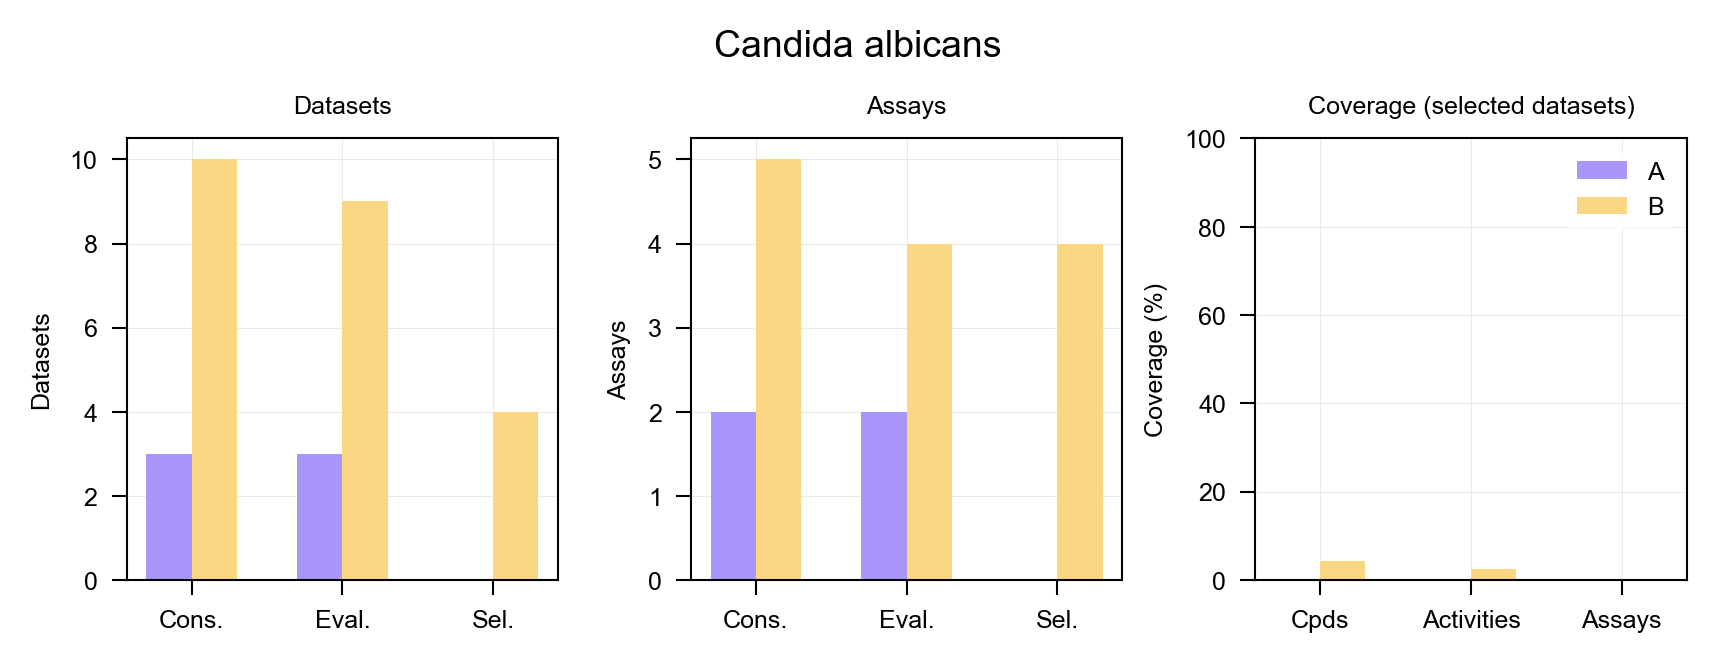

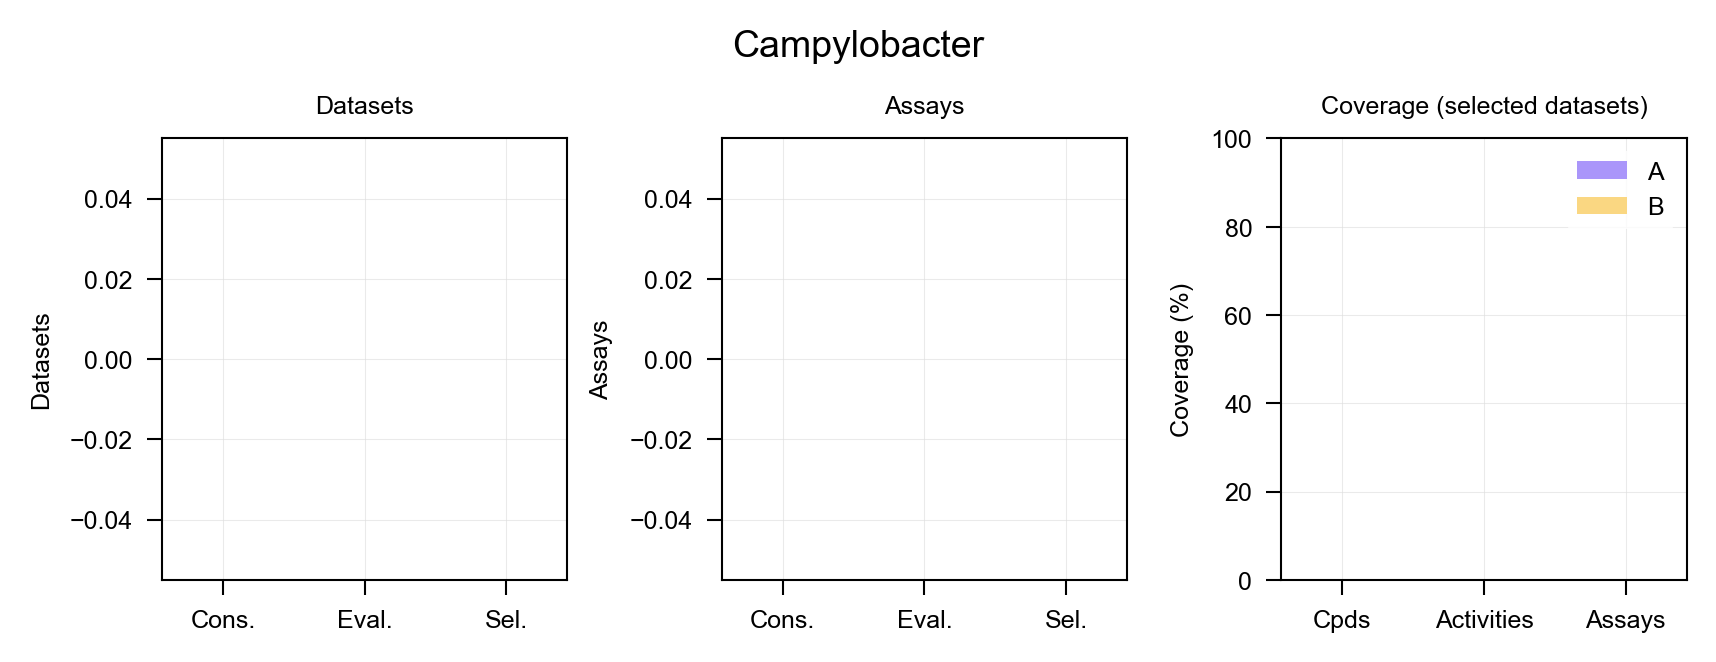

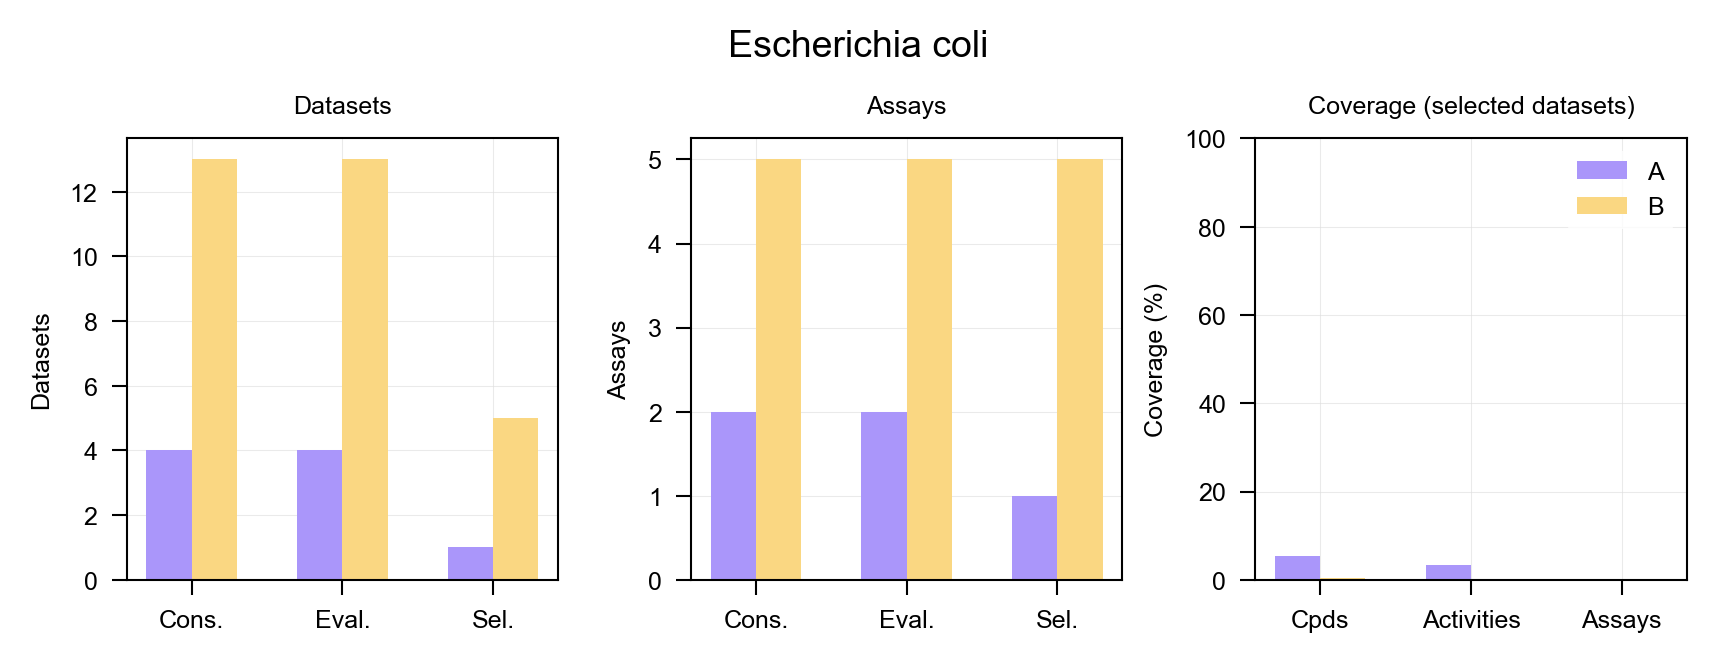

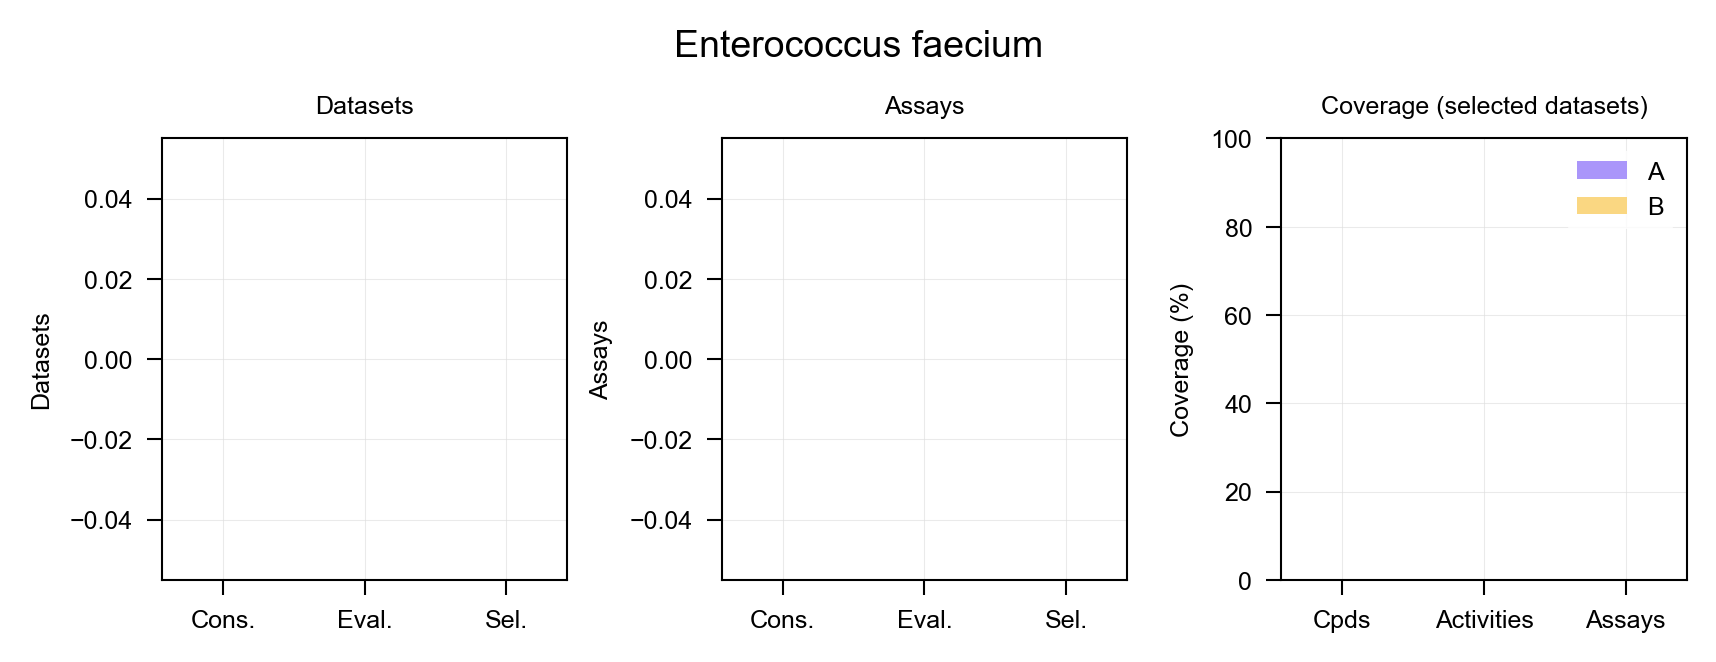

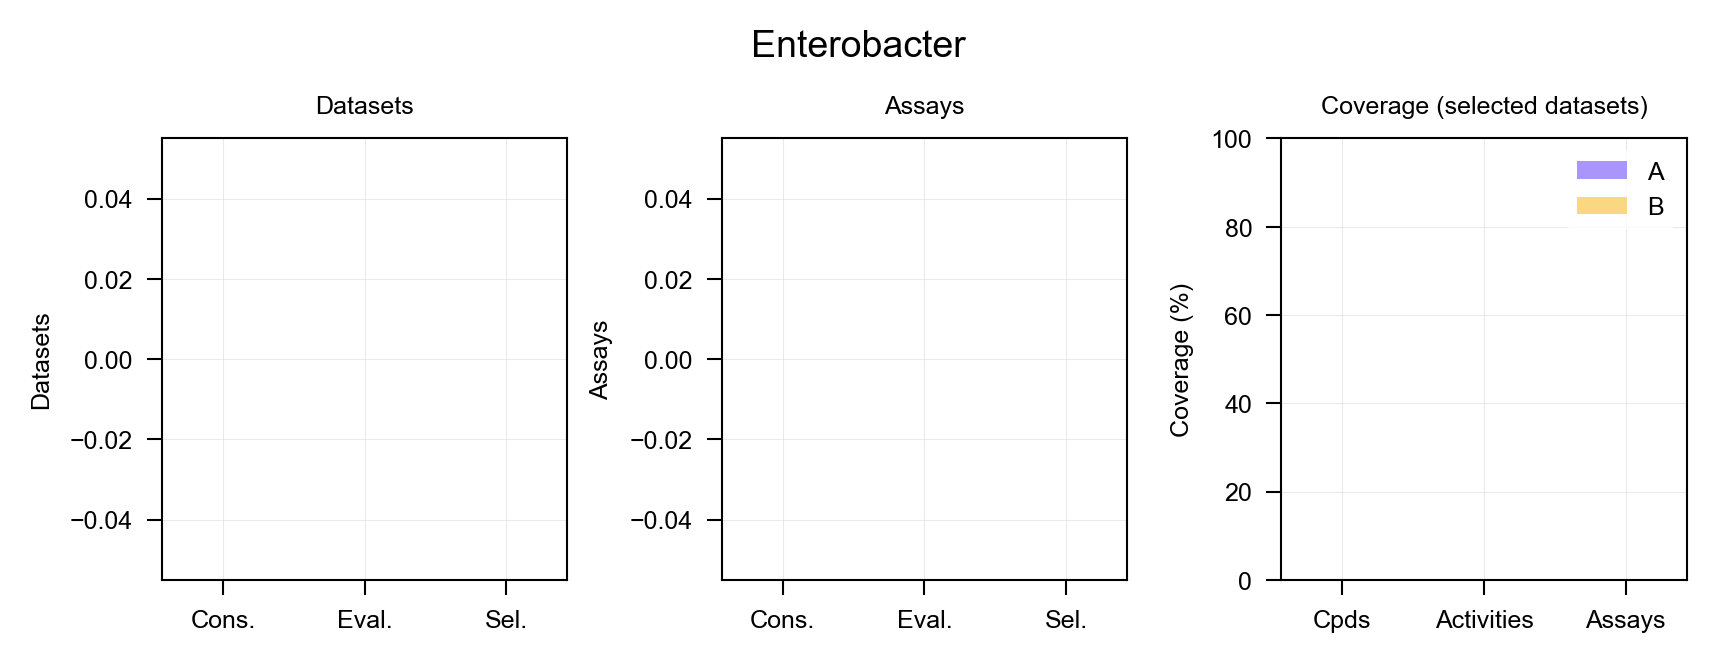

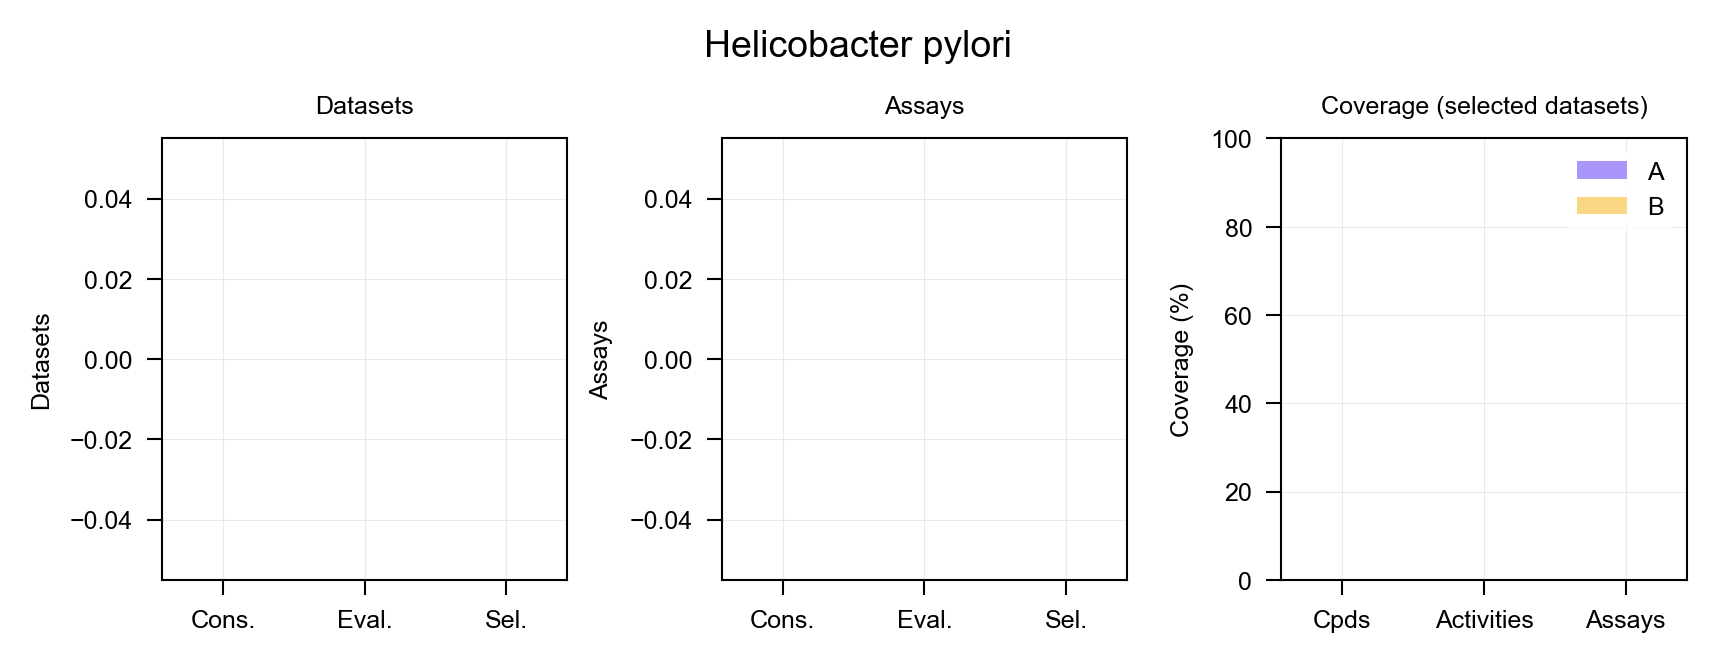

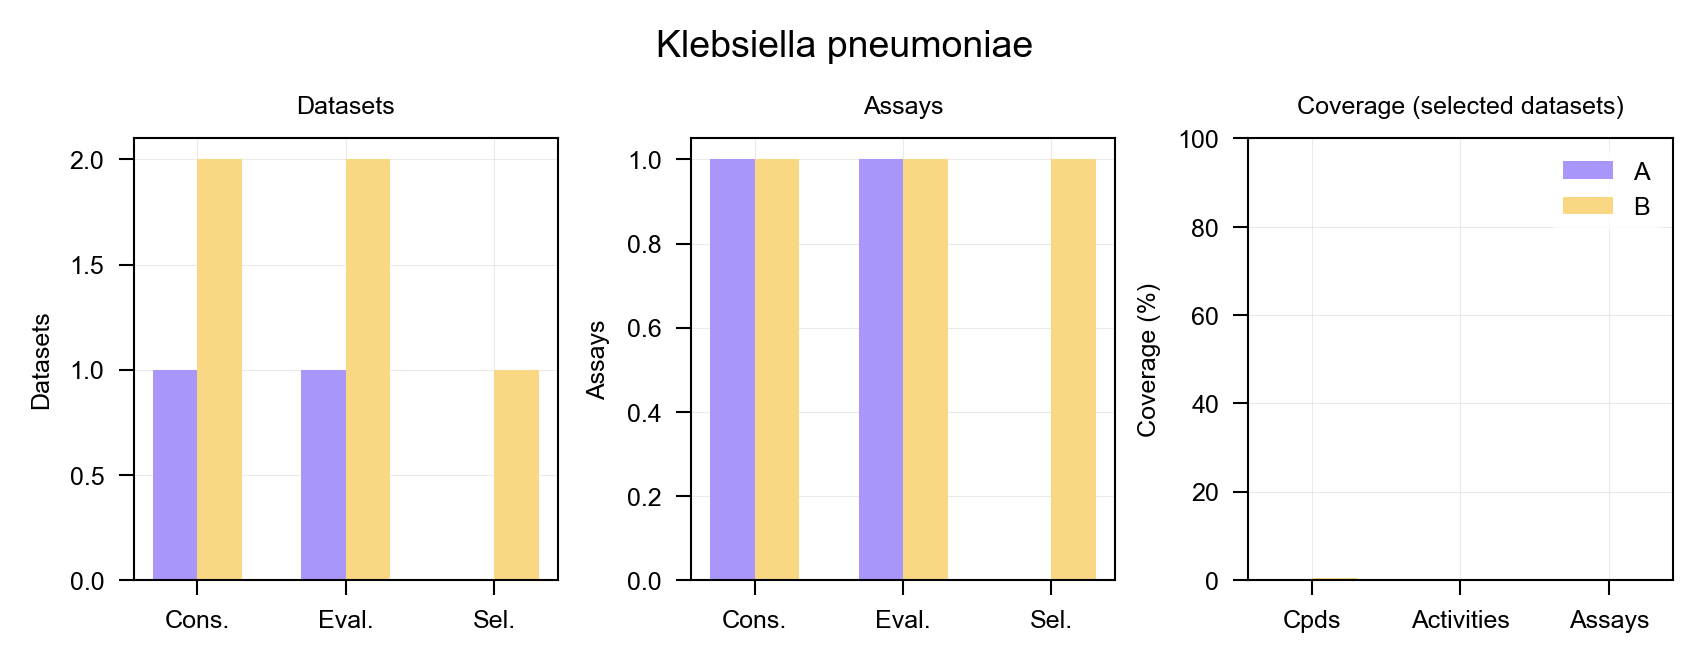

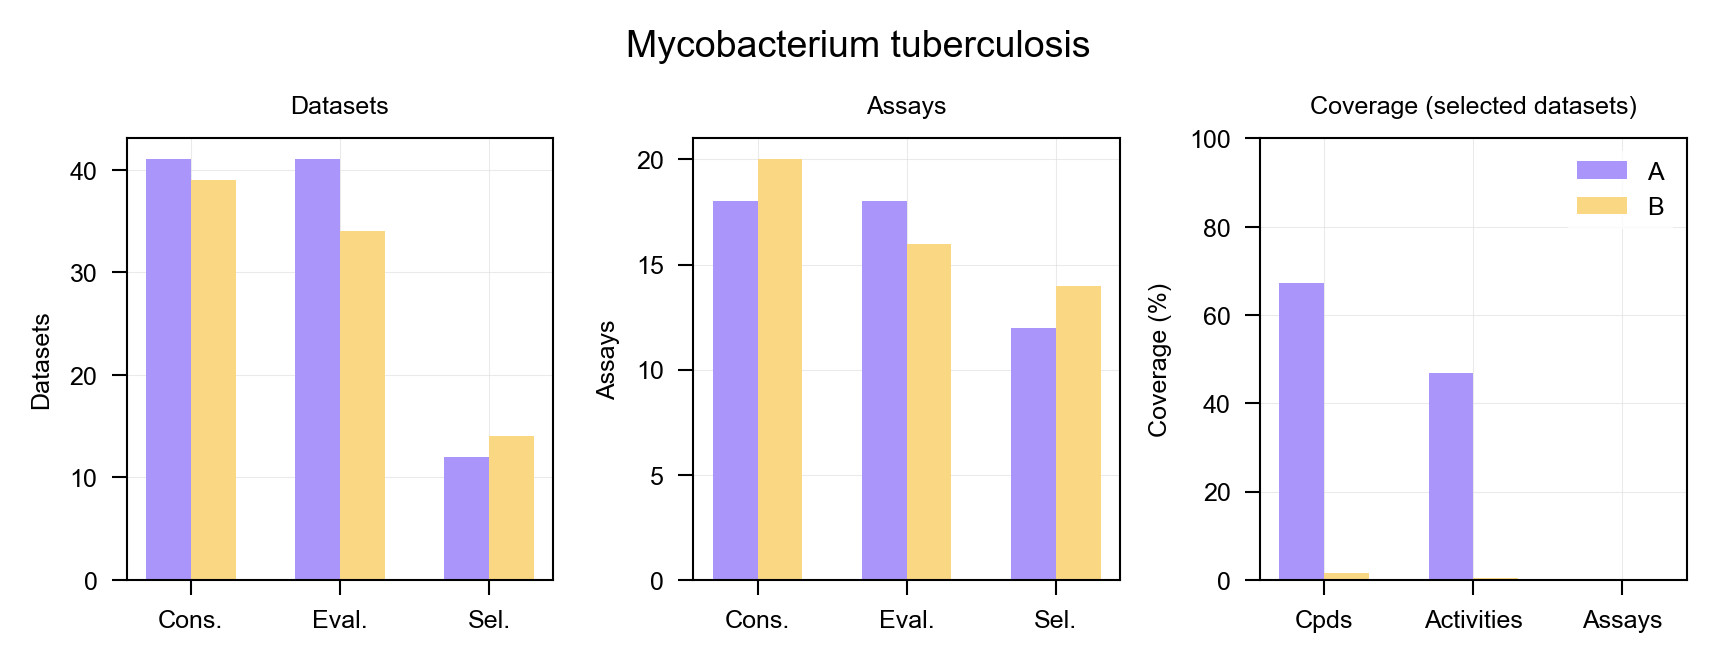

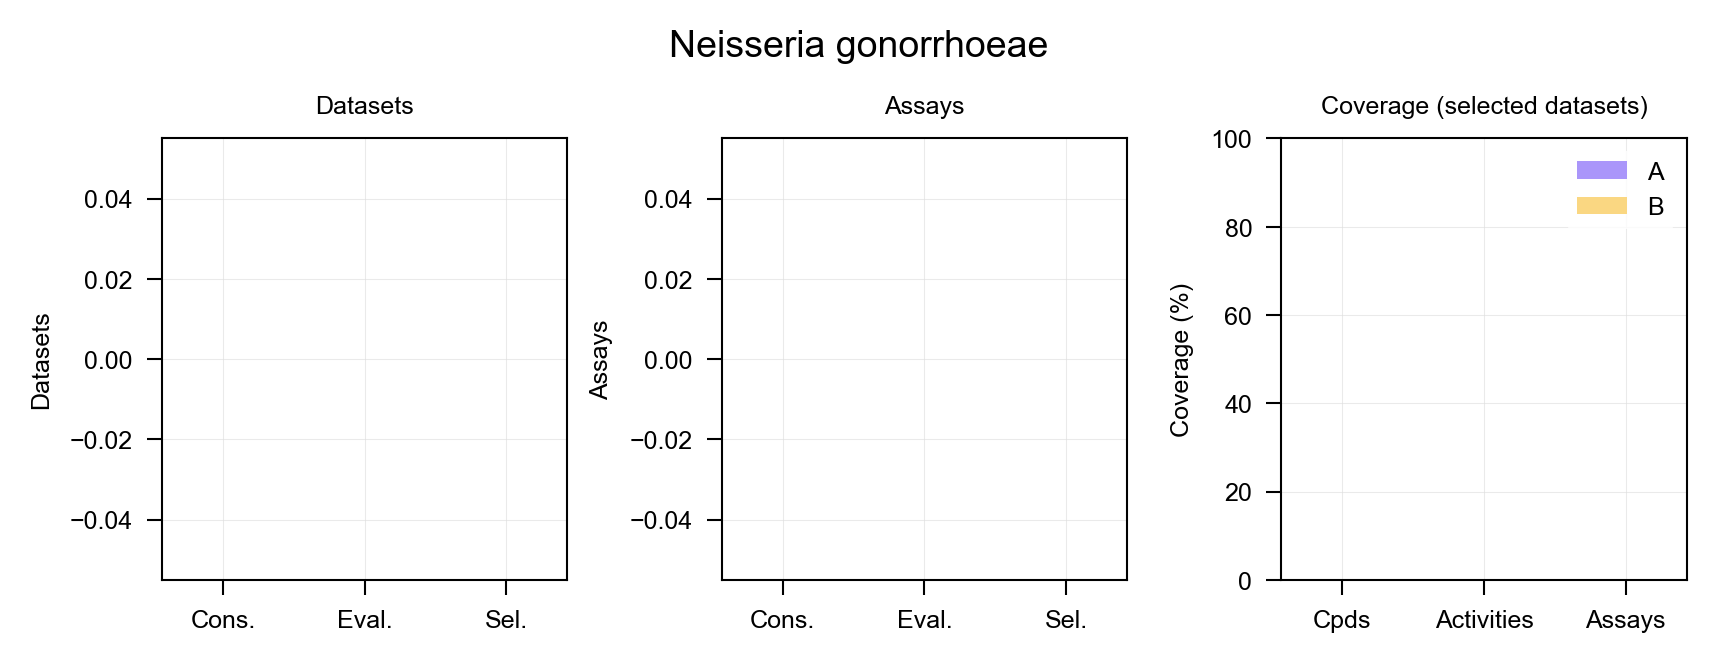

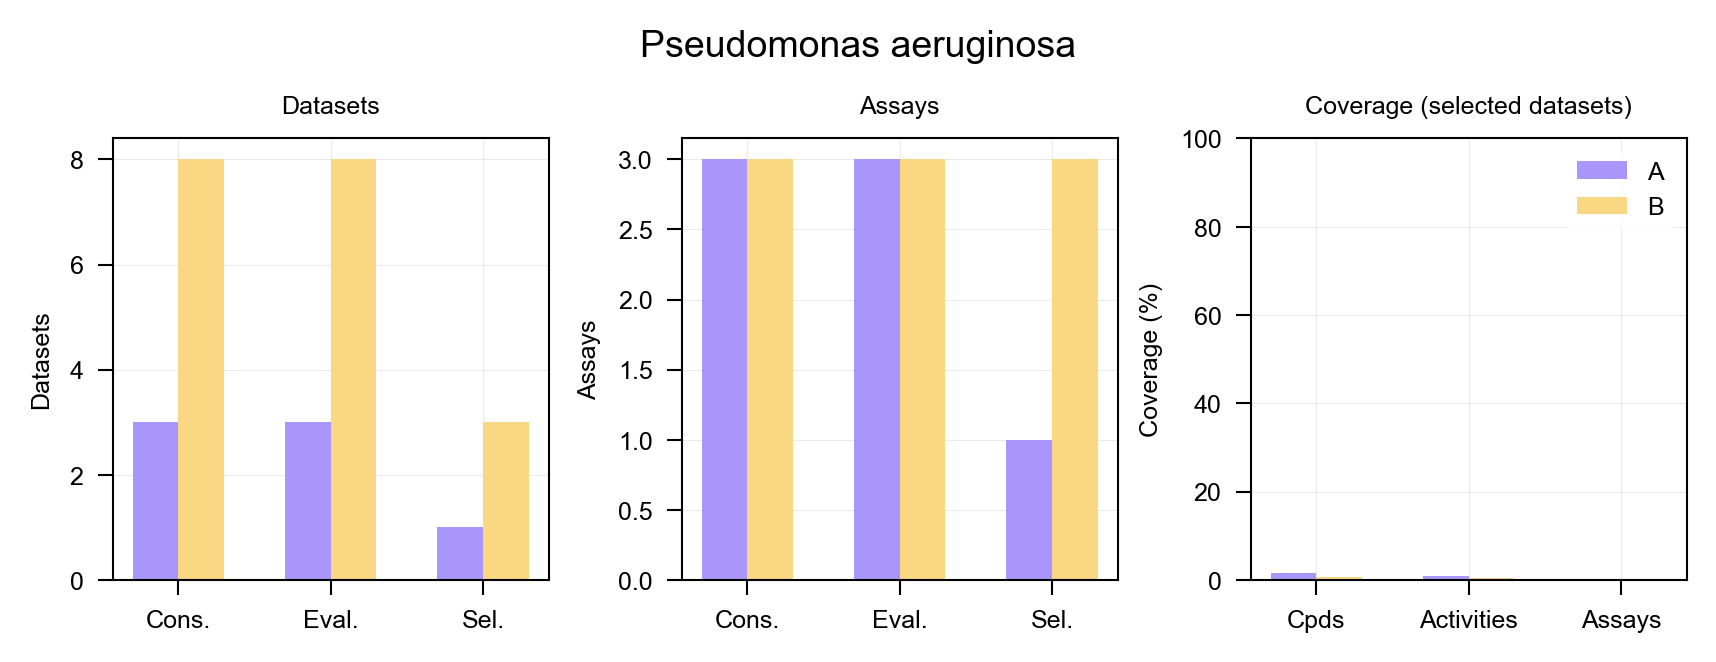

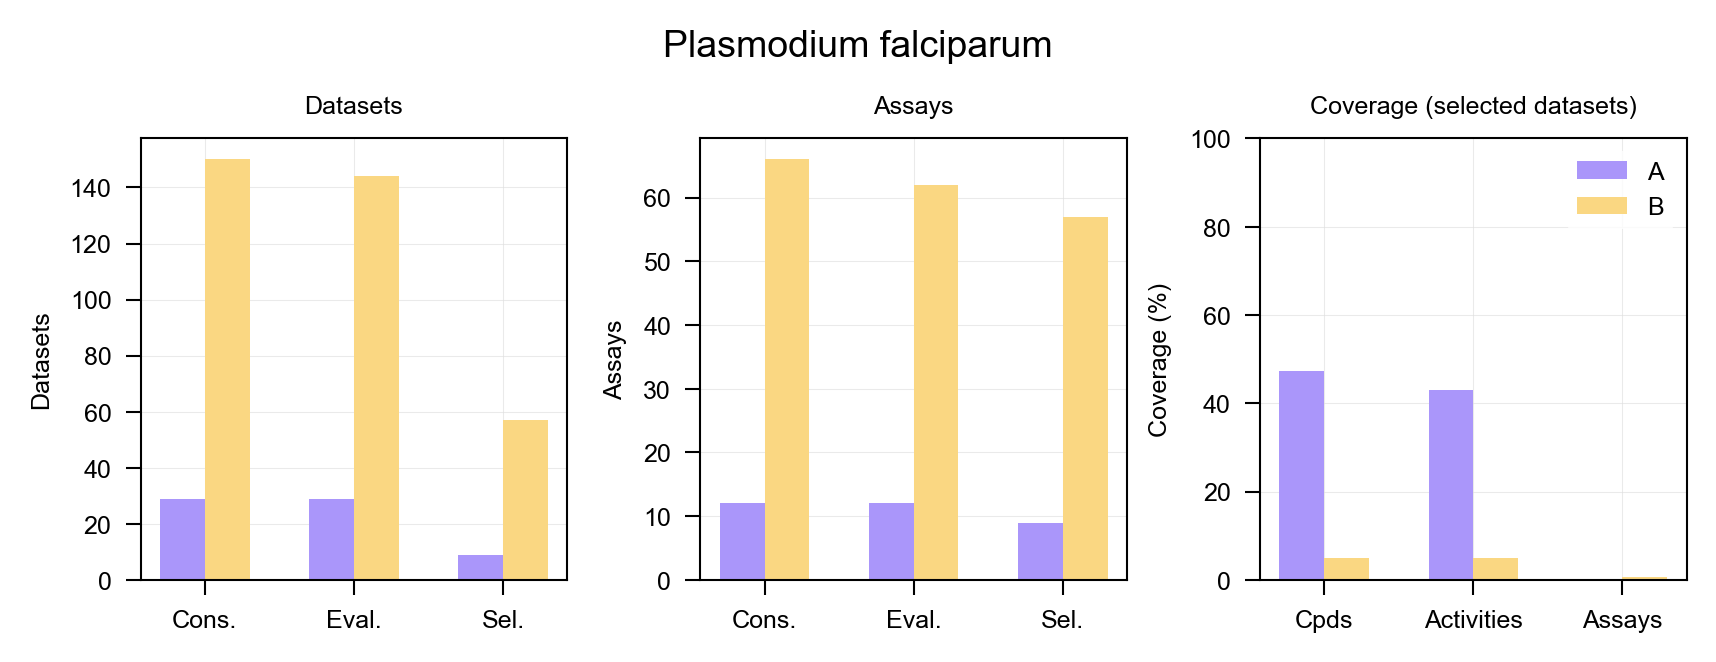

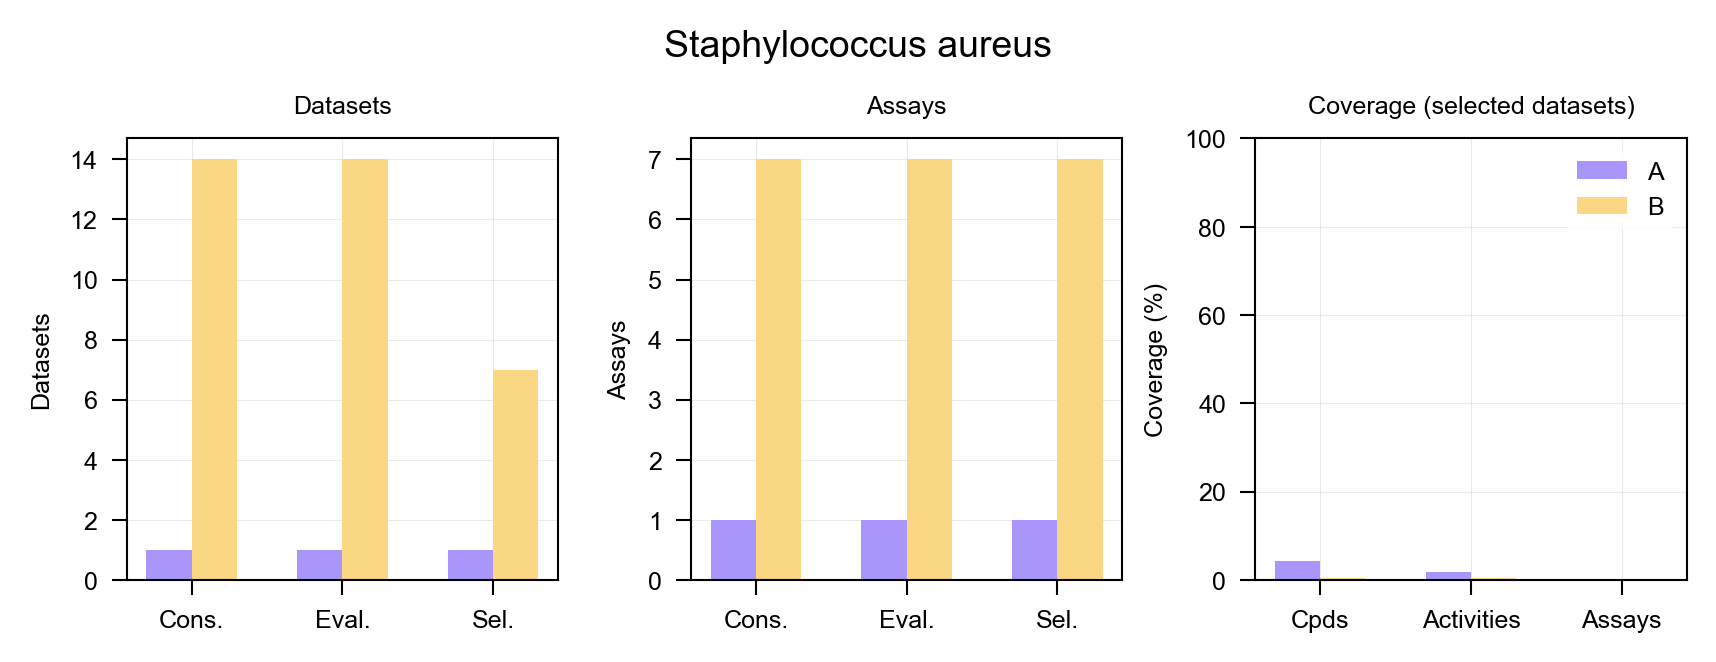

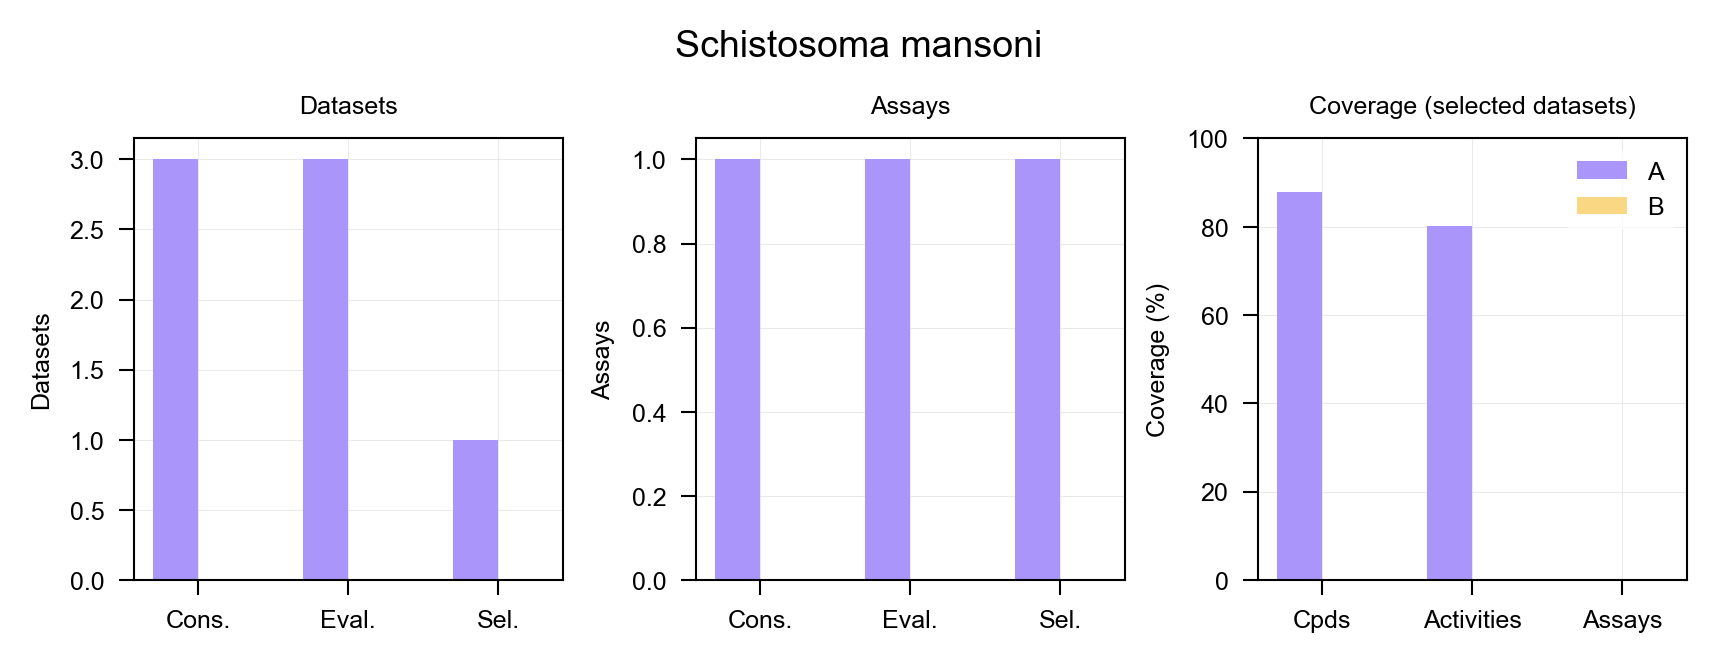

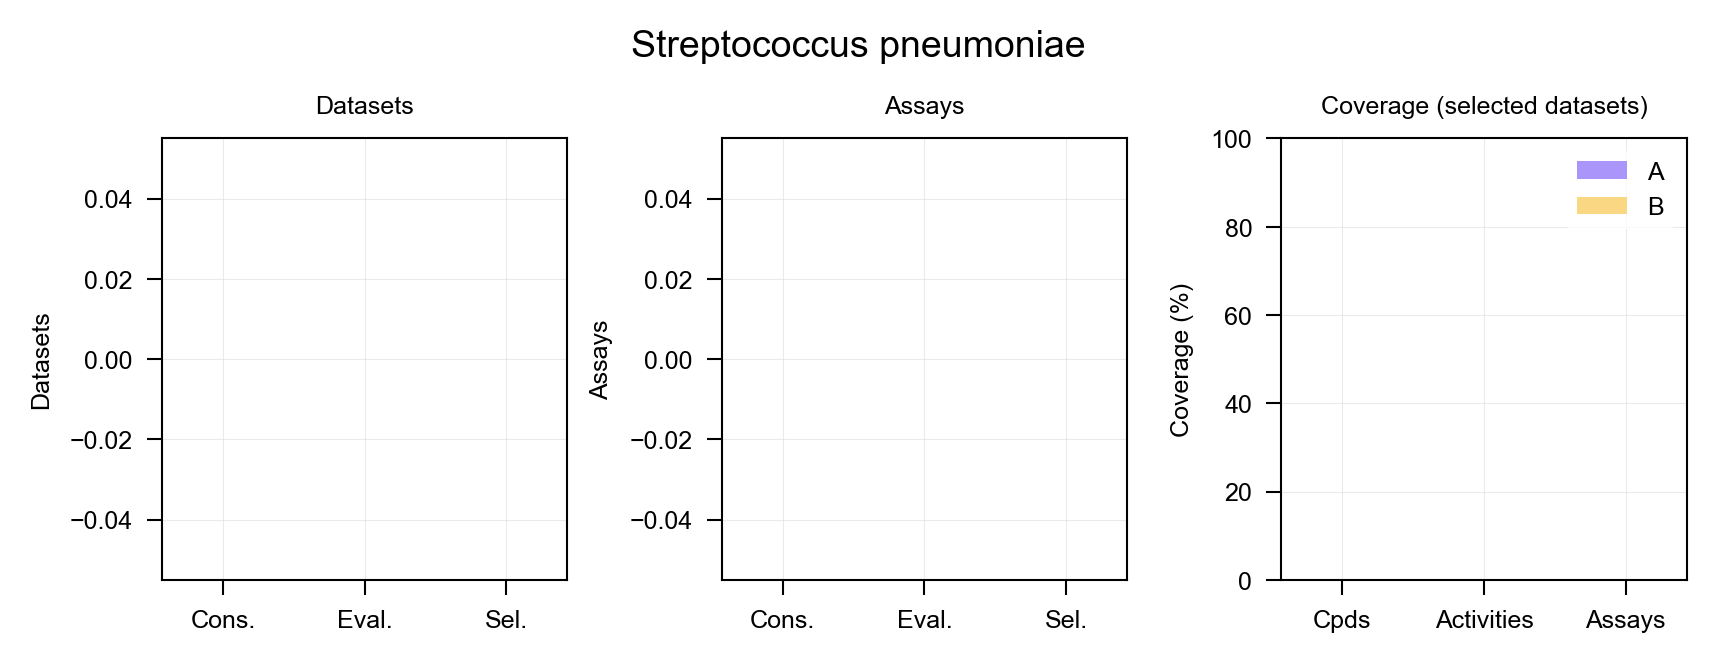

In [3]:
ec = stylia.ErsiliaColors()
stages  = ["Cons.", "Eval.", "Sel."]
metrics = ["Cpds", "Activities", "Assays"]
x = np.arange(3)
w = 0.3

def make_filename(assay_id, activity_type, unit, dataset_type, cutoff):
    base = f"{assay_id}_{activity_type}_{str(unit).replace('/', 'FwdS')}"
    if dataset_type == "quantitative":
        return f"{base}_qt_{cutoff}.csv.gz"
    elif dataset_type == "mixed":
        return f"{base}_mx_{cutoff}.csv.gz"

def load_unique_compounds(sel, base):
    """Return set of unique compound_chembl_id across all selected datasets."""
    zips = {
        "quantitative": os.path.join(base, "12_datasets", "datasets_qt.zip"),
        "mixed":        os.path.join(base, "12_datasets", "datasets_mx.zip"),
    }
    compound_ids = set()
    opened = {}
    for _, row in sel.iterrows():
        dtype = row["dataset_type"]
        fname = make_filename(row["assay_id"], row["activity_type"], row["unit"], dtype, row["cutoff"])
        if fname is None:
            continue
        if dtype not in opened:
            opened[dtype] = zipfile.ZipFile(zips[dtype])
        zf = opened[dtype]
        with zf.open(fname) as f:
            df = pd.read_csv(io.BytesIO(f.read()), usecols=["compound_chembl_id"], compression="gzip")
            compound_ids.update(df["compound_chembl_id"].astype(str))
    for zf in opened.values():
        zf.close()
    return compound_ids

for PATHOGEN_CODE, PATHOGEN_NAME in PATHOGENS.items():
    base = os.path.join(PATH_TO_OUTPUT, PATHOGEN_CODE)
    key_cols = ["assay_id", "activity_type", "unit"]

    sel_path = os.path.join(base, "14_individual_selected_LM.csv")
    if not os.path.exists(sel_path):
        print(f"Skipping {PATHOGEN_NAME} — step 14 not available")
        continue

    # Step 12 — considered
    df12 = pd.read_csv(os.path.join(base, "12_datasets.csv"))
    cons_a = df12[df12.apply(qualifies_a, axis=1)]
    cons_b = df12[df12.apply(qualifies_b, axis=1)]

    # Step 13 — evaluated
    df13 = pd.read_csv(os.path.join(base, "13_individual_LM.csv"))
    eval_a = df13[df13["label"] == "A"]
    eval_b = df13[df13["label"] == "B"]

    # Step 14 — selected
    df14 = pd.read_csv(sel_path)
    sel_a = df14[df14["label"] == "A"]
    sel_b = df14[df14["label"] == "B"]

    # Coverage denominators
    total_cpds       = len(pd.read_csv(os.path.join(base, "07_compound_counts.csv.gz")))
    assays_cleaned   = pd.read_csv(os.path.join(base, "08_assays_cleaned.csv"))
    total_assays     = len(assays_cleaned)
    total_activities = int(assays_cleaned["activities"].sum())
    df12_dedup       = df12[key_cols + ["activities"]].drop_duplicates(subset=key_cols)

    def coverage_pct(sel):
        if len(sel) == 0:
            return 0.0, 0.0, 0.0
        unique_cpds = load_unique_compounds(sel, base)
        cpds_pct = round(100 * len(unique_cpds) / total_cpds, 1)
        merged   = sel.merge(df12_dedup, on=key_cols, how="left")
        acts_pct = round(100 * merged["activities"].fillna(0).sum() / total_activities, 1)
        asys_pct = round(100 * n_assays(sel) / total_assays, 1)
        return cpds_pct, acts_pct, asys_pct

    cov_a = coverage_pct(sel_a)
    cov_b = coverage_pct(sel_b)

    # --- Plot ---
    fig, axs = stylia.create_figure(1, 3, width=0.8, height=0.3)

    ax = axs.next()
    ax.bar(x - w/2, [len(cons_a), len(eval_a), len(sel_a)], width=w, color=ec.purple, zorder=2)
    ax.bar(x + w/2, [len(cons_b), len(eval_b), len(sel_b)], width=w, color=ec.yellow,   zorder=2)
    ax.set_xticks(x)
    ax.set_xticklabels(stages)
    ax.set_xlabel("")
    stylia.label(ax, ylabel="Datasets", title="Datasets")

    ax = axs.next()
    ax.bar(x - w/2, [n_assays(cons_a), n_assays(eval_a), n_assays(sel_a)], width=w, color=ec.purple, zorder=2)
    ax.bar(x + w/2, [n_assays(cons_b), n_assays(eval_b), n_assays(sel_b)], width=w, color=ec.yellow,   zorder=2)
    ax.set_xticks(x)
    ax.set_xticklabels(stages)
    ax.set_xlabel("")
    stylia.label(ax, ylabel="Assays", title="Assays")

    ax = axs.next()
    ax.bar(x - w/2, list(cov_a), width=w, color=ec.purple, zorder=2, label="A")
    ax.bar(x + w/2, list(cov_b), width=w, color=ec.yellow,   zorder=2, label="B")
    ax.set_xticks(x)
    ax.set_xticklabels(metrics)
    ax.set_xlabel("")
    ax.set_ylim(0, 100)
    ax.legend()
    stylia.label(ax, ylabel="Coverage (%)", title="Coverage (selected datasets)")

    plt.suptitle(PATHOGEN_NAME, size=9)
    plt.tight_layout()
    plt.show()